# TINTOlib — Conversión de datos tabulares a imágenes

## 1. Instalación y librerías

In [15]:
# Instalar TINTOlib (ejecutar siempre al inicio en Colab)
!pip install tintolib -q

In [16]:
import importlib
import pkgutil
# Ver todos los módulos disponibles que contengan 'tinto'
mods = [m.name for m in pkgutil.iter_modules() if 'tinto' in m.name.lower()]
print(f'Módulos con "tinto": {mods}')

Módulos con "tinto": ['TINTOlib']


In [17]:
import TINTOlib
print(dir(TINTOlib))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__']


In [18]:
import os
import pkgutil
import TINTOlib

# Ver la ruta del paquete
print(f'Ruta: {TINTOlib.__path__}')

# Listar todos los submódulos
ruta = list(TINTOlib.__path__)[0]
print(f'\nArchivos en el paquete:')
for f in os.listdir(ruta):
    print(f'  {f}')

Ruta: ['/usr/local/lib/python3.12/dist-packages/TINTOlib']

Archivos en el paquete:
  supertml.py
  abstractImageMethod.py
  base.py
  paramImageMethod.py
  barGraph.py
  tinto.py
  distanceMatrix.py
  combination.py
  utils
  refined.py
  mappingMethod.py
  __init__.py
  featureWrap.py
  igtd.py
  clusters.py
  fotomics.py
  bie.py
  deepInsight.py
  __pycache__


In [23]:
!pip uninstall -y numpy pandas

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: pandas 2.2.3
Uninstalling pandas-2.2.3:
  Successfully uninstalled pandas-2.2.3


In [24]:
!pip install numpy==1.26.4 pandas==2.2.2 --force-reinstall --no-cache-dir

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 222.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 211.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 217.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.1/510.1 kB 236.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 87.7 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: tzdata
    Found existing installation: tzdata 2026.2
    Uninstalling tzdata-2026.2:
      Successfully uninstalled tzdata-2026.2
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.0:
      Successfully uninstalled six-1.17.0
  Attempting uninstall: python-dateutil
    Found existing installation:

In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
from TINTOlib.tinto import TINTO
print('✓ TINTO importado correctamente')

✓ TINTO importado correctamente


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

from TINTOlib.tinto import TINTO

# ── AJUSTA ESTAS RUTAS ────────────────────────────────────────────
CSV_PATH    = '/content/sweet_55_normalizado.csv'   # dataset normalizado del EDA
OUTPUT_DIR  = 'imagenes_tinto'             # carpeta donde se guardan las imágenes
# ─────────────────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Carpeta de salida: {OUTPUT_DIR}')

Carpeta de salida: imagenes_tinto


## 2. Carga del dataset normalizado

Cargamos el CSV normalizado generado en el notebook EDA.
Solo usamos las features fisiológicas seleccionadas — sin columnas de contexto ni metadata.

In [5]:
df = pd.read_csv(CSV_PATH)
print(f'Filas:    {len(df)}')
print(f'Columnas: {len(df.columns)}')
df.head(3)

Filas:    770
Columnas: 37


,ECG_mean_heart_rate,ECG_sdnn,ECG_rmssd,ECG_LF,ECG_HF,ECG_LFHF,"('ECG_mean_heart_rate', 'raw0')",ECG_QI_mean,mean_x,mean_y,...,user_id,timestamp,MAXIMUM_STRESS,PLEASURE,AROUSAL,DOMINANCE,ACTIVITY_list,CONSUMPTION_list,ACC_std_mean,stress_label
0,-1.491381,1.629018,1.588747,1.529593,1.754009,-0.413276,NaN,0.970375,-0.914459,-0.519939,...,user0091,2015-12-04 11:05:22,1.0,3.0,NaN,2.0,[2],[8],0.093661,S1
1,-0.257319,-0.436884,0.147060,0.034782,-0.457201,1.627296,NaN,1.000000,-0.697031,-0.861365,...,user0091,2015-12-04 14:37:43,1.0,4.0,1.0,1.0,"[2, 4, 6]",[8],0.047923,S1
2,0.139822,-0.030287,-0.214535,-0.833271,-0.492512,-0.932295,NaN,0.979992,1.112549,1.322528,...,user0091,2015-12-04 20:57:59,1.0,4.0,1.0,1.0,[1],[2],0.091517,S1


## 3. Preparación de datos para TINTOlib

TINTOlib espera un DataFrame donde:
- Las primeras N columnas son las **features numéricas** (ya normalizadas)
- La **última columna** es la etiqueta (target)

Preparamos ese formato con las 12 features seleccionadas y `stress_label` como target.

In [6]:
# Features fisiológicas seleccionadas (mismas que en el EDA)
FEATURE_COLS = [
    'ECG_mean_heart_rate',
    'ECG_sdnn',
    'ECG_rmssd',
    'ECG_LF',
    'ECG_HF',
    'ECG_LFHF',
    'mean_x',
    'mean_y',
    'mean_z',
    'GSR_mean',
    'TEMP_mean',
    'ACC_mag_mean',
]

# Verificar que existen en el CSV
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
print(f'Features disponibles ({len(FEATURE_COLS)}): {FEATURE_COLS}')

# Convertir etiquetas a numérico (TINTOlib requiere números)
# S1=0, S2=1, S3=2
label_map = {'S1': 0, 'S2': 1, 'S3': 2}
df['target'] = df['stress_label'].map(label_map)

print(f'\nMapeo de etiquetas: {label_map}')
print(f'Distribución target:')
print(df['target'].value_counts().sort_index())

Features disponibles (12): ['ECG_mean_heart_rate', 'ECG_sdnn', 'ECG_rmssd', 'ECG_LF', 'ECG_HF', 'ECG_LFHF', 'mean_x', 'mean_y', 'mean_z', 'GSR_mean', 'TEMP_mean', 'ACC_mag_mean']

Mapeo de etiquetas: {'S1': 0, 'S2': 1, 'S3': 2}
Distribución target:
target
0    443
1    220
2    107
Name: count, dtype: int64


In [7]:
# Construir DataFrame en el formato que espera TINTOlib:
# [feature_1, feature_2, ..., feature_N, target]
df_tinto = df[FEATURE_COLS + ['target']].dropna().reset_index(drop=True)

# Asegurar que target sea entero
df_tinto['target'] = df_tinto['target'].astype(int)

print(f'Filas para TINTOlib: {len(df_tinto)}')
print(f'Columnas:            {list(df_tinto.columns)}')
print(f'\nPrimeras 3 filas:')
df_tinto.head(3)

Filas para TINTOlib: 770
Columnas:            ['ECG_mean_heart_rate', 'ECG_sdnn', 'ECG_rmssd', 'ECG_LF', 'ECG_HF', 'ECG_LFHF', 'mean_x', 'mean_y', 'mean_z', 'GSR_mean', 'TEMP_mean', 'ACC_mag_mean', 'target']

Primeras 3 filas:


,ECG_mean_heart_rate,ECG_sdnn,ECG_rmssd,ECG_LF,ECG_HF,ECG_LFHF,mean_x,mean_y,mean_z,GSR_mean,TEMP_mean,ACC_mag_mean,target
0,-1.491381,1.629018,1.588747,1.529593,1.754009,-0.413276,-0.914459,-0.519939,-1.044317,0.640519,-0.652397,1.112198,0
1,-0.257319,-0.436884,0.147060,0.034782,-0.457201,1.627296,-0.697031,-0.861365,1.056918,1.058004,0.290461,0.746097,0
2,0.139822,-0.030287,-0.214535,-0.833271,-0.492512,-0.932295,1.112549,1.322528,-0.753772,0.436245,-0.652397,-0.615058,0


## 4. Generación de imágenes con TINTO

TINTO es el método principal de TINTOlib. Proyecta las features en un espacio 2D usando una técnica similar a PCA, y luego pinta cada feature como un píxel coloreado según su valor.

Cada fila del DataFrame → una imagen de `image_size x image_size` píxeles.

In [8]:
import inspect
from TINTOlib.tinto import TINTO
print(inspect.signature(TINTO.__init__))

(self, problem=None, transformer=MinMaxScaler(), verbose=None, pixels=20, algorithm='PCA', blur=False, submatrix=True, amplification=3.141592653589793, distance=2, steps=4, option='mean', times=4, train_m=True, zoom=1, format='png', cmap='binary', random_seed=1)


In [9]:

tinto = TINTO(
    pixels      = 64,       # imágenes de 20x20 px
    blur        = True,     # suavizado gaussiano
    zoom        = 1,        # sin zoom adicional
    random_seed = 42,       # reproducibilidad
    verbose     = True,     # mostrar progreso
    algorithm   = 'PCA',    # proyección 2D con PCA
    cmap        = 'binary'  # escala de grises
)

print('✓ TINTO configurado correctamente')
print(f'  Tamaño imagen: 20x20 px')
print(f'  Algoritmo:     PCA')
print(f'  Blur:          True')
print(f'  Imágenes a generar: {len(df_tinto)}')

✓ TINTO configurado correctamente
  Tamaño imagen: 20x20 px
  Algoritmo:     PCA
  Blur:          True
  Imágenes a generar: 770


In [10]:
# Ver todos los métodos de la clase TINTO
metodos = [m for m in dir(tinto) if not m.startswith('_')]
print('Métodos disponibles:')
for m in metodos:
    print(f'  {m}')

Métodos disponibles:
  algorithm
  amplification
  blur
  cmap
  default_algorithm
  default_amplification
  default_blur
  default_cmap
  default_distance
  default_format
  default_option
  default_pixels
  default_random_seed
  default_steps
  default_submatrix
  default_times
  default_train_m
  default_zoom
  distance
  error_pos
  fit
  fit_transform
  format
  loadHyperparameters
  option
  pixels
  problem
  random_seed
  saveHyperparameters
  steps
  submatrix
  times
  train_m
  transform
  transformer
  verbose
  zoom


In [11]:
# Generar imágenes
# TINTOlib crea una subcarpeta por clase dentro de OUTPUT_DIR:
#   imagenes_tinto/
#       0/  ← S1 (sin estrés)
#       1/  ← S2 (leve)
#       2/  ← S3 (alto)

# Generar imágenes con fit_transform
# fit_transform = fit + transform en un solo paso
# Recibe el DataFrame y la carpeta de salida

tinto.fit_transform(df_tinto, OUTPUT_DIR)

print(f'\n✓ Imágenes generadas en: {OUTPUT_DIR}/')

Generating and saving the synthetic images:  30%|███       | 30/100 [00:00<00:00, 199.37it/s]

Data successfully loaded.
Selected algorithm: PCA
The folder imagenes_tinto is already created...


Images generated and saved: 100%|██████████| 100.0/100 [00:01<00:00, 52.86it/s]

Fit-Transform process completed.

✓ Imágenes generadas en: imagenes_tinto/


In [12]:
# Verificar estructura de carpetas y conteo por clase
print('Estructura de carpetas generada:')
total = 0
conteo_clase = {}
nombres_clase = {0: 'S1 Sin estrés', 1: 'S2 Leve', 2: 'S3 Alto'}

for clase in sorted(os.listdir(OUTPUT_DIR)):
    clase_path = os.path.join(OUTPUT_DIR, clase)
    if os.path.isdir(clase_path):
        n_imgs = len([f for f in os.listdir(clase_path)
                      if f.endswith('.png')])
        conteo_clase[clase] = n_imgs
        total += n_imgs
        nombre = nombres_clase.get(int(clase), clase)
        print(f'  {OUTPUT_DIR}/{clase}/  ({nombre}): {n_imgs} imágenes')

print(f'\n  Total imágenes: {total}')

Estructura de carpetas generada:
  imagenes_tinto/00/  (S1 Sin estrés): 443 imágenes
  imagenes_tinto/01/  (S2 Leve): 220 imágenes
  imagenes_tinto/02/  (S3 Alto): 107 imágenes

  Total imágenes: 770


## 5. Visualización de imágenes generadas

Mostramos una grilla de imágenes de ejemplo por clase para verificar que la conversión fue correcta. Cada imagen representa el estado fisiológico de un usuario en un momento de medición.

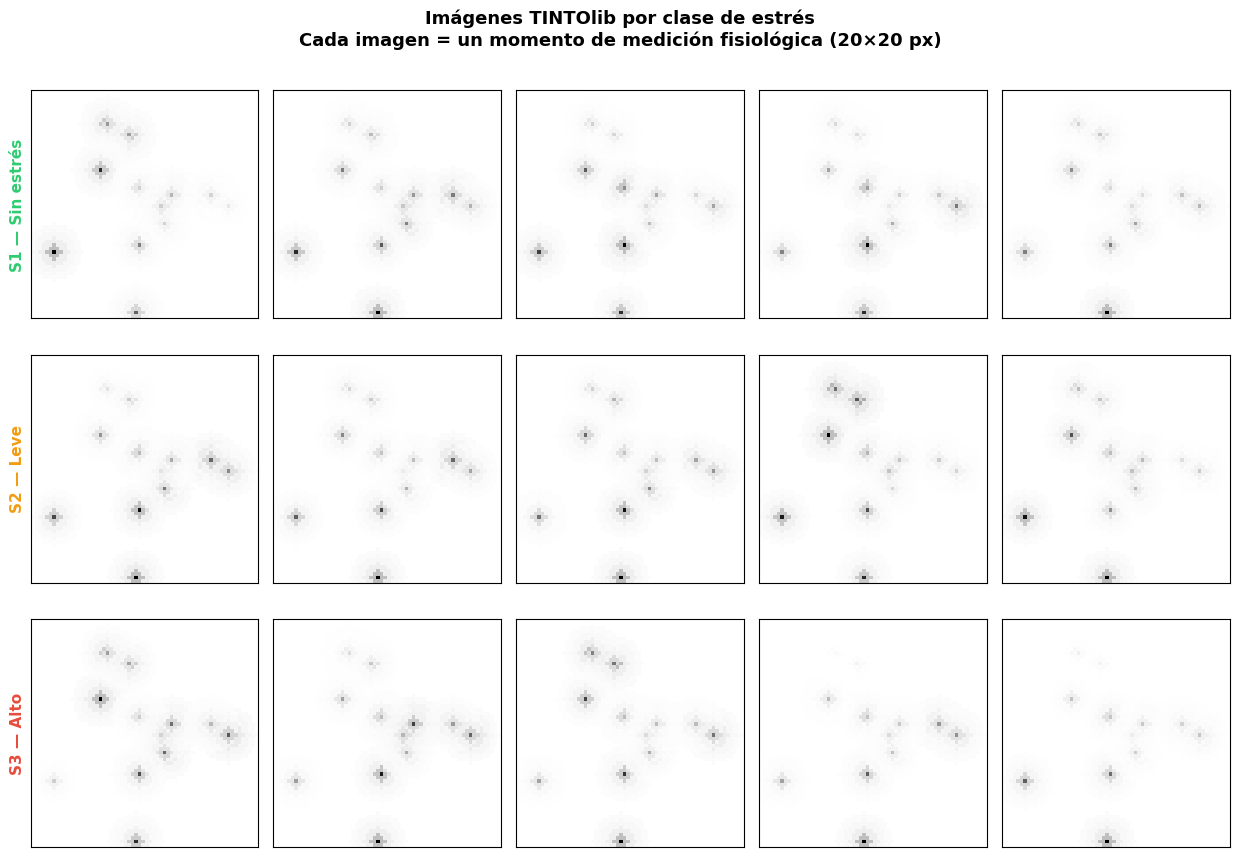

✓ Grilla guardada: tinto_grid_imagenes.png


In [13]:
import cv2

def cargar_imagenes_clase(clase_dir, n=5):
    """Carga las primeras n imágenes de una carpeta de clase."""
    archivos = sorted([
        f for f in os.listdir(clase_dir) if f.endswith('.png')
    ])[:n]
    imagenes = []
    for f in archivos:
        img = cv2.imread(os.path.join(clase_dir, f))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        imagenes.append(img)
    return imagenes


# Mostrar grilla: 3 filas (clases) x 5 columnas (ejemplos)
N_EJEMPLOS  = 5
clases_dirs = {
    'S1 — Sin estrés': os.path.join(OUTPUT_DIR, '00'),
    'S2 — Leve':       os.path.join(OUTPUT_DIR, '01'),
    'S3 — Alto':       os.path.join(OUTPUT_DIR, '02'),
}
colores_titulo = ['#2ecc71', '#f39c12', '#e74c3c']

fig, axes = plt.subplots(3, N_EJEMPLOS, figsize=(N_EJEMPLOS*2.5, 9))

for row, ((nombre_clase, clase_dir), color) in enumerate(
        zip(clases_dirs.items(), colores_titulo)):

    if not os.path.exists(clase_dir):
        print(f'⚠ Carpeta no encontrada: {clase_dir}')
        continue

    imagenes = cargar_imagenes_clase(clase_dir, N_EJEMPLOS)

    for col in range(N_EJEMPLOS):
        ax = axes[row][col]
        if col < len(imagenes):
            ax.imshow(imagenes[col])
        else:
            ax.axis('off')
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(nombre_clase, fontsize=11,
                          fontweight='bold', color=color)

fig.suptitle('Imágenes TINTOlib por clase de estrés\n'
             'Cada imagen = un momento de medición fisiológica (20×20 px)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tinto_grid_imagenes.png', bbox_inches='tight')
plt.show()
print('✓ Grilla guardada: tinto_grid_imagenes.png')

In [14]:
# Verificar dimensiones de las imágenes generadas
primer_clase = os.path.join(OUTPUT_DIR, '00')
primer_img   = sorted(os.listdir(primer_clase))[0]
img_test     = cv2.imread(os.path.join(primer_clase, primer_img))

print(f'Dimensiones de imagen: {img_test.shape}')
print(f'  Alto:   {img_test.shape[0]} px')
print(f'  Ancho:  {img_test.shape[1]} px')
print(f'  Canales:{img_test.shape[2]} (RGB)')

Dimensiones de imagen: (64, 64, 3)
  Alto:   64 px
  Ancho:  64 px
  Canales:3 (RGB)


## 6. Guardado de rutas y etiquetas

Creamos un CSV con la ruta de cada imagen y su etiqueta. Este archivo será la entrada del notebook 05 donde la CNN extrae los embeddings.

In [15]:
# Construir DataFrame con ruta de imagen y etiqueta
registros = []
nombre_clase_map = {'0': 'S1', '1': 'S2', '2': 'S3'}

for clase_num in sorted(os.listdir(OUTPUT_DIR)):
    clase_path = os.path.join(OUTPUT_DIR, clase_num)
    if not os.path.isdir(clase_path):
        continue
    for fname in sorted(os.listdir(clase_path)):
        if fname.endswith('.png'):
            registros.append({
                'imagen_path' : os.path.join(clase_path, fname),
                'clase_num'   : int(clase_num),
                'stress_label': nombre_clase_map.get(clase_num, clase_num)
            })

df_imagenes = pd.DataFrame(registros)
df_imagenes.to_csv('imagenes_index.csv', index=False)

print(f'✓ Index guardado: imagenes_index.csv')
print(f'  Total imágenes indexadas: {len(df_imagenes)}')
print(f'\n  Distribución:')
print(df_imagenes['stress_label'].value_counts().sort_index())
print(f'\n  Primeras filas:')
df_imagenes.head(5)

✓ Index guardado: imagenes_index.csv
  Total imágenes indexadas: 770

  Distribución:
stress_label
00    443
01    220
02    107
Name: count, dtype: int64

  Primeras filas:


,imagen_path,clase_num,stress_label
0,imagenes_tinto/00/000000.png,0,00
1,imagenes_tinto/00/000001.png,0,00
2,imagenes_tinto/00/000002.png,0,00
3,imagenes_tinto/00/000003.png,0,00
4,imagenes_tinto/00/000004.png,0,00


In [16]:
# Resumen final
print('=' * 50)
print('RESUMEN — TINTOlib')
print('=' * 50)
print(f"""
  Método usado:       TINTO
  Features entrada:   {len(FEATURE_COLS)} columnas fisiológicas
  Imágenes generadas: {len(df_imagenes)}
  Tamaño imagen:      {img_test.shape[0]}x{img_test.shape[1]} px
  Carpeta imágenes:   {OUTPUT_DIR}/
  Index imágenes:     imagenes_index.csv

RESUMEN — TINTOlib

  Método usado:       TINTO
  Features entrada:   12 columnas fisiológicas
  Imágenes generadas: 770
  Tamaño imagen:      64x64 px
  Carpeta imágenes:   imagenes_tinto/
  Index imágenes:     imagenes_index.csv

  SIGUIENTE PASO → 05_CNN_embeddings.ipynb
  Cargar las imágenes, entrenar CNN y extraer
  embeddings para los modelos ML



In [17]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
